In [29]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [8]:
#Reading CSV
df = pd.read_csv('Cleaned_data.csv')

In [9]:
#Seprating Importatnt Columns
Imp_df = df[['pl_orbsmax', 'pl_eqt', 'st_teff', 'st_rad']]

In [10]:
Imp_df

,pl_orbsmax,pl_eqt,st_teff,st_rad
0,330.00000,1800.0,3993.0,1.31316
1,330.00000,1800.0,4060.0,1.35200
2,118.00000,1450.0,3100.0,0.84000
3,46.00000,1150.0,2825.0,0.21887
4,0.01544,1958.0,5234.0,0.94300
...,...,...,...,...
15550,28.40000,275.0,4760.0,0.67900
15551,0.06702,1147.0,5870.0,1.10000
15552,0.06839,1169.8,6037.0,1.10000
15553,0.21960,614.0,5627.0,1.36170


In [11]:
#Checking relationship of inputs with outputs

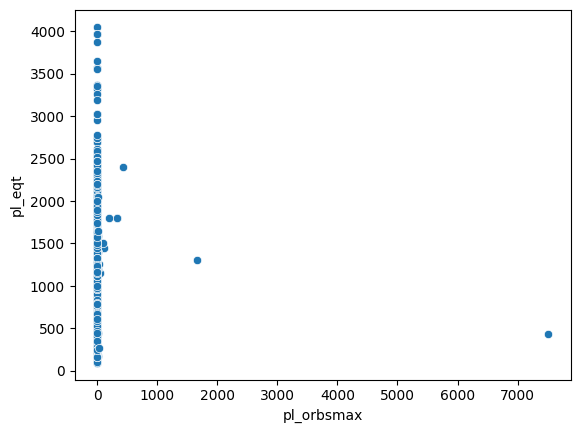

In [20]:
sns.scatterplot(x=Imp_df.pl_orbsmax, y=Imp_df.pl_eqt);

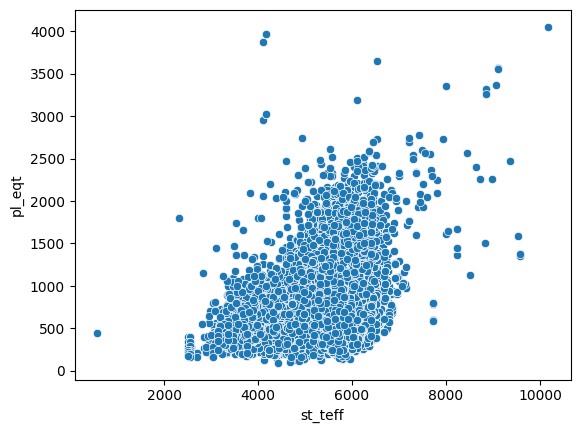

In [21]:
sns.scatterplot(x=Imp_df.st_teff, y=Imp_df.pl_eqt);

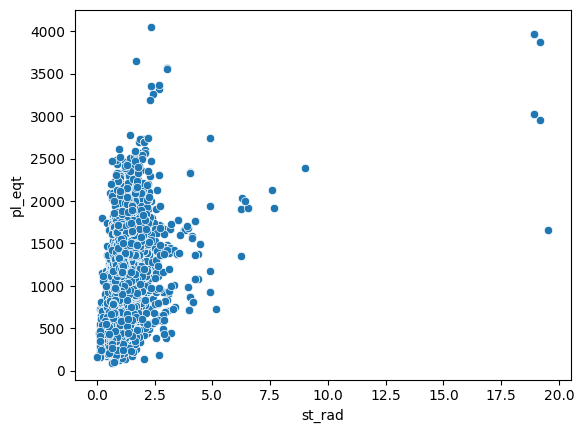

In [27]:
sns.scatterplot(x=Imp_df.st_rad, y=Imp_df.pl_eqt);

In [28]:
#Checking Correlations
print('Orbit', Imp_df.pl_eqt.corr(Imp_df.pl_orbsmax))
print('Star Tmp', Imp_df.pl_eqt.corr(Imp_df.st_teff))
print('Star Radius', Imp_df.pl_eqt.corr(Imp_df.st_rad))

Orbit -0.003360243393735257
Star Tmp 0.3739814511122548
Star Radius 0.40126932240642504


In [31]:
#Train test split
targets = Imp_df['pl_eqt']
inputs = Imp_df[['pl_orbsmax', 'st_teff', 'st_rad']]

X_train, X_test, y_train, y_test = train_test_split(
    inputs, targets, test_size=0.2, random_state=42
)

In [32]:
#Training Model-A
Model_A = LinearRegression()
Model_A.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = Model_A.predict(X_test)

In [42]:
#Evaluation

In [43]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 274.6451597731724


In [44]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 127380.72350989188


In [45]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 356.9043618532728


In [46]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.20901737246873375


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 274.6451597731724
MSE: 127380.72350989188
RMSE: 356.9043618532728
R2: 0.20901737246873375


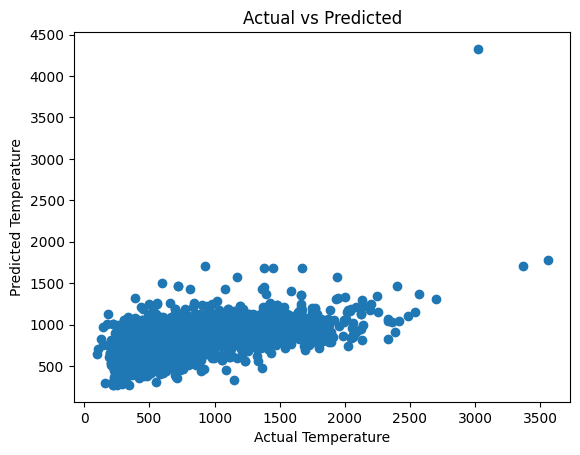

In [48]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.show()

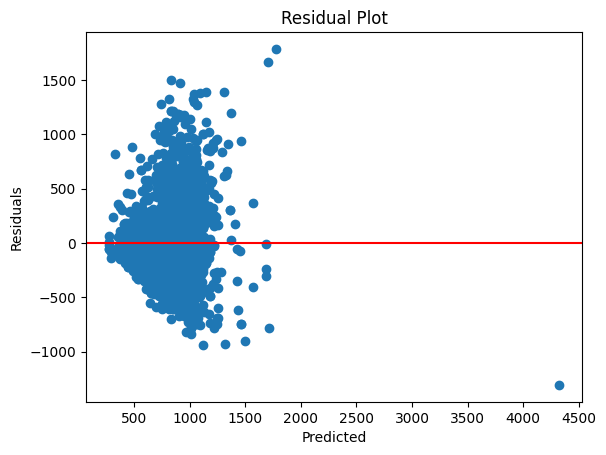

In [49]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

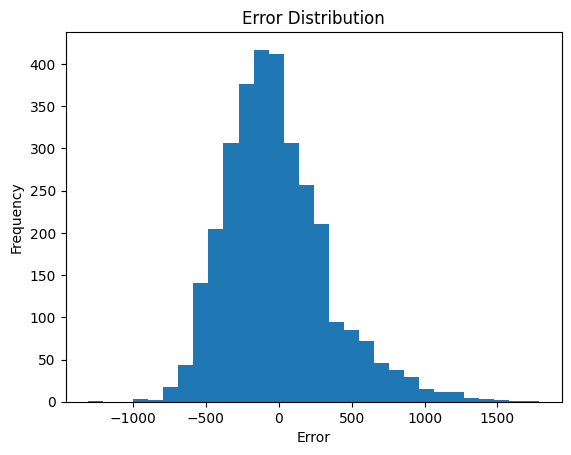

In [50]:
plt.hist(residuals, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [51]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(Model_A, "models/Model_A.pkl")

['models/Model_A.pkl']

In [52]:
#Training model B

In [53]:
import numpy as np

df_log = Imp_df.copy()

In [56]:
df_log["log_pl_orbsmax"] = np.log(df_log["pl_orbsmax"])
df_log["log_st_teff"] = np.log(df_log["st_teff"])
df_log["log_st_rad"] = np.log(df_log["st_rad"])

In [57]:
df_log = df_log.dropna()

In [59]:
inputs_log = df_log[["log_pl_orbsmax", "log_st_teff", "log_st_rad"]]
targets_log = Imp_df.pl_eqt

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs_log, targets_log,
    test_size=0.2,
    random_state=42
)

In [63]:
Model_B = LinearRegression()

In [64]:
Model_B.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = Model_B.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 96.80009276864128
MSE: 34855.62033960848
RMSE: 186.69659970017793
R2: 0.783560735087874


In [76]:
print(Model_B.coef_)
print(Model_B.intercept_)

[-371.91316978  413.24083504  526.76379017]
-3539.206831393332


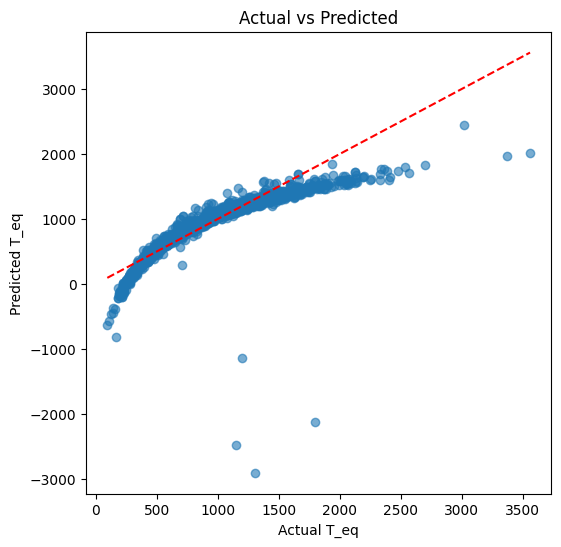

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual T_eq")
plt.ylabel("Predicted T_eq")
plt.title("Actual vs Predicted")
plt.show()

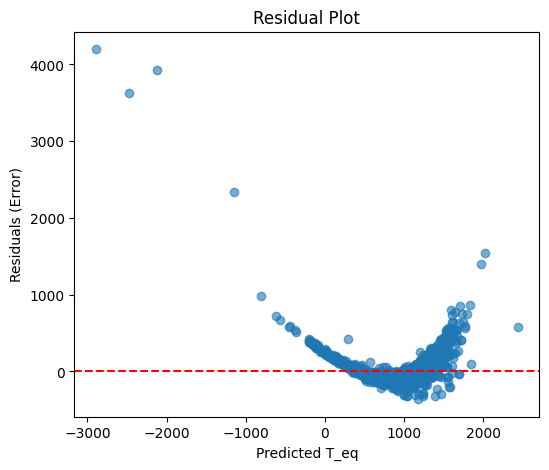

In [78]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted T_eq")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

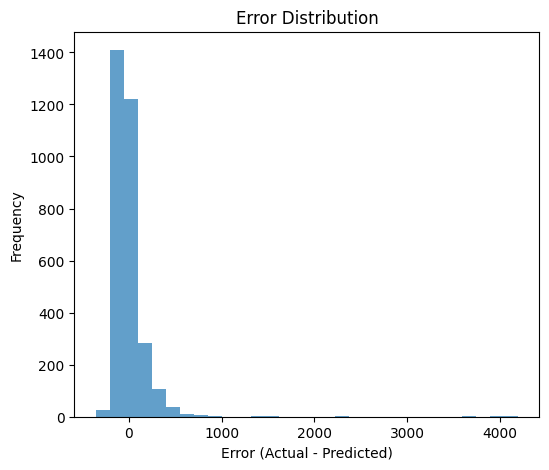

In [79]:
plt.figure(figsize=(6,5))
plt.hist(residuals, bins=30, alpha=0.7)

plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()

In [80]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(Model_A, "models/Model_B.pkl")

['models/Model_B.pkl']